# 08 · Do amyloid and tau PET measures improve the prediction?

**Research question 2.** Among people who have PET, does adding the PET numbers to the clinical model improve prediction of dementia?

**Why the design is deliberately small.** The PET cohorts have a few hundred to about a thousand participants and well under 100 events available for fitting. A flexible model with dozens of inputs would overfit. So the experiment uses **late fusion**:

1. A clinical model (XGBoost, no PET) is trained on **all** landmark visits of the training participants, whether or not they have PET. This uses the big cohort.
2. For a PET participant, that model produces one number: the clinical risk.
3. A small logistic regression combines the clinical risk with two amyloid measures (Centiloids, positive/negative) and, where available, two tau measures (meta-temporal and entorhinal SUVR, scaled within tracer). Only this last step is fitted on PET participants, and it has at most nine coefficients.

Comparisons are **paired**: the same held-out participants, scored with and without PET. Results come from `scripts/train_pet.py`.

### Two designs, and why both are shown

A scan has a date and so does each clinic visit. Which visit should the scan be attached to?

| Design | Index visit | Strength | Weakness |
|---|---|---|---|
| **Strict** (main) | The first visit **on or after** the scan, within one year | The PET value is never newer than the visit. No information from the future | Small: recent scans have little follow-up after that visit |
| **Nearest** (sensitivity) | The visit closest to the scan, within one year either side | About three times larger | In about four of five cases the scan was taken *after* the visit (a median of 55 days later), so the PET value is slightly newer than the clinical data it is combined with. This can only flatter PET |

The first version of this analysis used only the nearest design. Cross-checking showed the timing problem, so the strict design was added and made the main one. If both designs give the same answer, the answer does not depend on that choice.

The main horizon is **2 years**, because follow-up after PET is short; 3 years is shown as well.

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

nu.set_style()
allres = json.loads((nu.REPORTS / "phase4_pet_results.json").read_text())
LABEL = {"y_dementia_2y": "Dementia within 2 years", "y_dementia_3y": "Dementia within 3 years"}
pd.DataFrame({(d.capitalize(), LABEL[t]): {s: f"{v['n']:,} ({v['events']})" for s, v in allres[d][t]["cohort"].items()}
              for d in allres for t in allres[d]}).rename_axis("Participants (events)")

Strict                          \
                      Dementia within 2 years Dementia within 3 years   
Participants (events)                                                   
train                                331 (25)                245 (31)   
val                                    71 (3)                  56 (5)   
test                                   65 (5)                  52 (6)   
external                             290 (24)                205 (28)   

                                      Nearest                          
                      Dementia within 2 years Dementia within 3 years  
Participants (events)                                                  
train                                911 (85)               649 (110)  
val                                  200 (11)                140 (21)  
test                                 189 (20)                133 (23)  
external                             676 (50)                482 (67)

The internal test sets are tiny (5 to 23 events). On their own they cannot detect anything but a very large effect. The external centres have more, and since neither set was used for fitting, the two are pooled in the main comparison.

In [2]:
def table(design, target, subset):
    rows = {}
    for ev in ["test", "external", "test + external"]:
        for name, m in allres[design][target][subset][ev].items():
            if "auroc" not in m:
                continue
            rows[(ev, name)] = {"n": m["n"], "Events": m["events"], "AUROC (95% interval)": f"{m['auroc']:.3f} ({m['auroc_ci'][0]:.3f}-{m['auroc_ci'][1]:.3f})",
                                "Gain in AUROC vs clinical only": "reference" if "delta_auroc" not in m else f"{m['delta_auroc']:+.4f} ({m['delta_auroc_ci'][0]:+.4f} to {m['delta_auroc_ci'][1]:+.4f})"}
    return pd.DataFrame(rows).T

b = allres["strict"]["y_dementia_2y"]["has amyloid PET"]
print("STRICT design, 2 years, people with amyloid PET. Fusion fitted on", b["train_n"], "participants with", b["train_events"], "events")
table("strict", "y_dementia_2y", "has amyloid PET")

STRICT design, 2 years, people with amyloid PET. Fusion fitted on 375 participants with 24 events


n Events AUROC (95% interval)  \
test            Clinical only        64      5  0.939 (0.852-1.000)   
                Clinical + amyloid   64      5  0.976 (0.934-1.000)   
external        Clinical only       271     23  0.958 (0.927-0.981)   
                Clinical + amyloid  271     23  0.955 (0.925-0.979)   
test + external Clinical only       335     28  0.955 (0.930-0.977)   
                Clinical + amyloid  335     28  0.959 (0.935-0.979)   

                                   Gain in AUROC vs clinical only  
test            Clinical only                           reference  
                Clinical + amyloid   +0.0373 (+0.0000 to +0.1131)  
external        Clinical only                           reference  
                Clinical + amyloid   -0.0028 (-0.0112 to +0.0068)  
test + external Clinical only                           reference  
                Clinical + amyloid   +0.0041 (-0.0065 to +0.0165)

In [3]:
b = allres["nearest"]["y_dementia_2y"]["has amyloid PET"]
print("NEAREST design, 2 years, people with amyloid PET. Fusion fitted on", b["train_n"], "participants with", b["train_events"], "events")
table("nearest", "y_dementia_2y", "has amyloid PET")

NEAREST design, 2 years, people with amyloid PET. Fusion fitted on 1033 participants with 85 events


n Events AUROC (95% interval)  \
test            Clinical only       175     17  0.931 (0.884-0.967)   
                Clinical + amyloid  175     17  0.930 (0.885-0.967)   
external        Clinical only       642     47  0.960 (0.942-0.975)   
                Clinical + amyloid  642     47  0.960 (0.941-0.975)   
test + external Clinical only       817     64  0.951 (0.934-0.966)   
                Clinical + amyloid  817     64  0.951 (0.934-0.966)   

                                   Gain in AUROC vs clinical only  
test            Clinical only                           reference  
                Clinical + amyloid   -0.0004 (-0.0071 to +0.0067)  
external        Clinical only                           reference  
                Clinical + amyloid   -0.0004 (-0.0028 to +0.0021)  
test + external Clinical only                           reference  
                Clinical + amyloid   +0.0000 (-0.0021 to +0.0022)

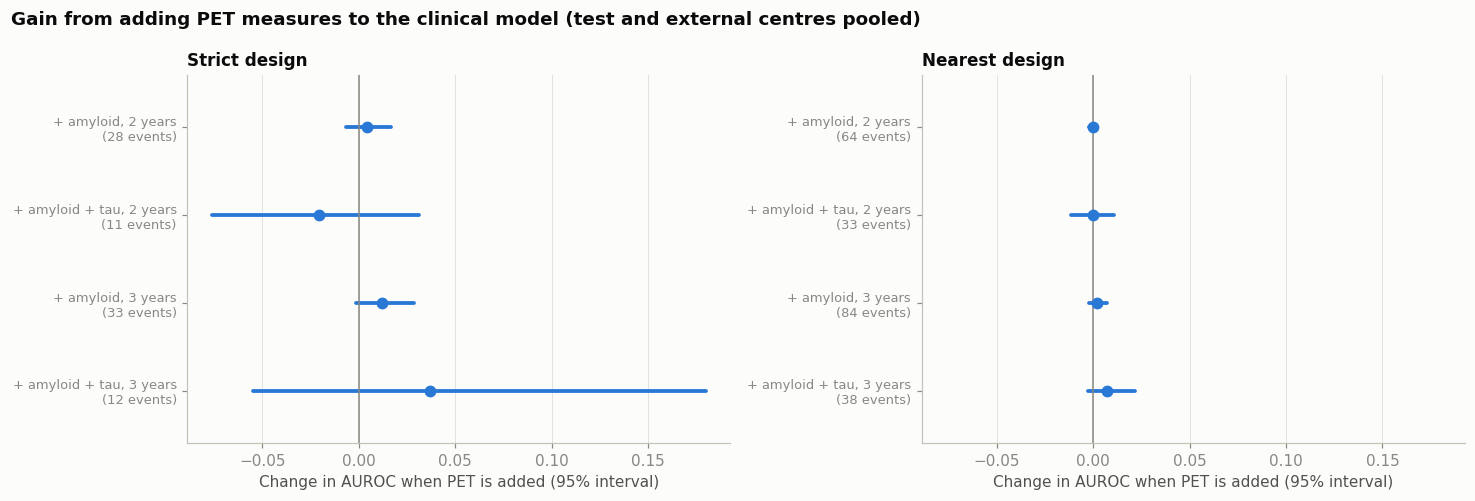

Events    Gain  \
Strict  Dementia within 2 years Clinical + amyloid          28.0  0.0041   
                                Clinical + amyloid + tau    11.0 -0.0208   
        Dementia within 3 years Clinical + amyloid          33.0  0.0118   
                                Clinical + amyloid + tau    12.0  0.0367   
Nearest Dementia within 2 years Clinical + amyloid          64.0  0.0000   
                                Clinical + amyloid + tau    33.0 -0.0002   
        Dementia within 3 years Clinical + amyloid          84.0  0.0021   
                                Clinical + amyloid + tau    38.0  0.0074   

                                                          95% low  95% high  
Strict  Dementia within 2 years Clinical + amyloid        -0.0065    0.0165  
                                Clinical + amyloid + tau  -0.0761    0.0312  
        Dementia within 3 years Clinical + amyloid        -0.0016    0.0286  
                                Clinical + amyloid + tau  -0.0549    0.1798  
Nearest Dementia within 2 years Clinical + amyloid        -0.0021    0.0022  
                                Clinical + amyloid + tau  -0.0116    0.0107  
        Dementia within 3 years Clinical + amyloid        -0.0019    0.0072  
                                Clinical + amyloid + tau  -0.0029    0.0220

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharex=True)
for ax, design in zip(axes, ["strict", "nearest"]):
    items = []
    for target in ["y_dementia_2y", "y_dementia_3y"]:
        for subset, names in [("has amyloid PET", ["Clinical + amyloid"]), ("has amyloid and tau PET", ["Clinical + amyloid + tau"])]:
            for name in names:
                m = allres[design][target][subset]["test + external"][name]
                items.append((f"{name.replace('Clinical + ', '+ ')}, {LABEL[target][-7:]}\n({m['events']} events)", m))
    for i, (lab, m) in enumerate(items[::-1]):
        ax.plot(m["delta_auroc_ci"], [i, i], color=nu.BLUE, lw=2.5, solid_capstyle="round"); ax.scatter([m["delta_auroc"]], [i], color=nu.BLUE, s=45, zorder=3)
    ax.axvline(0, color=nu.MUTED, lw=1); ax.set_yticks(range(len(items)), [l for l, _ in items[::-1]], fontsize=8.5); ax.set_ylim(-0.6, len(items) - 0.4)
    ax.set_xlabel("Change in AUROC when PET is added (95% interval)"); ax.grid(axis="y", visible=False)
    ax.set_title(f"{design.capitalize()} design")
fig.suptitle("Gain from adding PET measures to the clinical model (test and external centres pooled)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "08_pet_gain"); plt.show()
rows = {}
for design in allres:
    for target in allres[design]:
        for subset, name in [("has amyloid PET", "Clinical + amyloid"), ("has amyloid and tau PET", "Clinical + amyloid + tau")]:
            m = allres[design][target][subset]["test + external"][name]
            rows[(design.capitalize(), LABEL[target], name)] = {"Events": m["events"], "Gain": round(m["delta_auroc"], 4), "95% low": round(m["delta_auroc_ci"][0], 4), "95% high": round(m["delta_auroc_ci"][1], 4)}
pd.DataFrame(rows).T

## Result

**No gain from PET was demonstrated in either design.** Every interval for the change in AUROC includes zero.

* **Nearest design** (more data, PET slightly favoured): the gains are within about 0.01 of zero with tight intervals. For amyloid at 2 years the gain is 0.000 (interval -0.002 to +0.002).
* **Strict design** (clean, small): point estimates are a little higher (amyloid +0.004 at 2 years and +0.012 at 3 years), but with only about 30 events the intervals are wide and include zero. The 3-year amyloid interval (-0.002 to +0.029) comes close to excluding zero, so a small real benefit cannot be ruled out.

The two designs agree on the conclusion and differ in how firmly they support it. The nearest design says "any gain is very small"; the strict design says "we cannot tell with this few events".

## But amyloid status clearly matters on its own

In [5]:
rows = {}
for design in allres:
    for target in allres[design]:
        for dx, d in allres[design][target]["conversion_rate_by_amyloid_status"].items():
            for status, v in d.items():
                rows[(design.capitalize(), LABEL[target][-7:], dx, f"Amyloid {status}")] = {"Participants": int(v["n"]), "Converted": int(v["events"]), "Rate %": round(v["events"] / v["n"] * 100, 1)}
rates = pd.DataFrame(rows).T
rates

Participants  Converted  \
Strict  2 years normal at index Amyloid negative         157.0        0.0   
                                Amyloid positive          75.0        0.0   
                MCI at index    Amyloid negative          32.0        3.0   
                                Amyloid positive          59.0       21.0   
        3 years normal at index Amyloid negative         111.0        0.0   
                                Amyloid positive          46.0        1.0   
                MCI at index    Amyloid negative          24.0        3.0   
                                Amyloid positive          51.0       25.0   
Nearest 2 years normal at index Amyloid negative         363.0        1.0   
                                Amyloid positive         170.0        0.0   
                MCI at index    Amyloid negative          86.0        6.0   
                                Amyloid positive         154.0       52.0   
        3 years normal at index Amyloid negative         263.0        1.0   
                                Amyloid positive         122.0        1.0   
                MCI at index    Amyloid negative          53.0       12.0   
                                Amyloid positive         122.0       64.0   

                                                  Rate %  
Strict  2 years normal at index Amyloid negative     0.0  
                                Amyloid positive     0.0  
                MCI at index    Amyloid negative     9.4  
                                Amyloid positive    35.6  
        3 years normal at index Amyloid negative     0.0  
                                Amyloid positive     2.2  
                MCI at index    Amyloid negative    12.5  
                                Amyloid positive    49.0  
Nearest 2 years normal at index Amyloid negative     0.3  
                                Amyloid positive     0.0  
                MCI at index    Amyloid negative     7.0  
                                Amyloid positive    33.8  
        3 years normal at index Amyloid negative     0.4  
                                Amyloid positive     0.8  
                MCI at index    Amyloid negative    22.6  
                                Amyloid positive    52.5

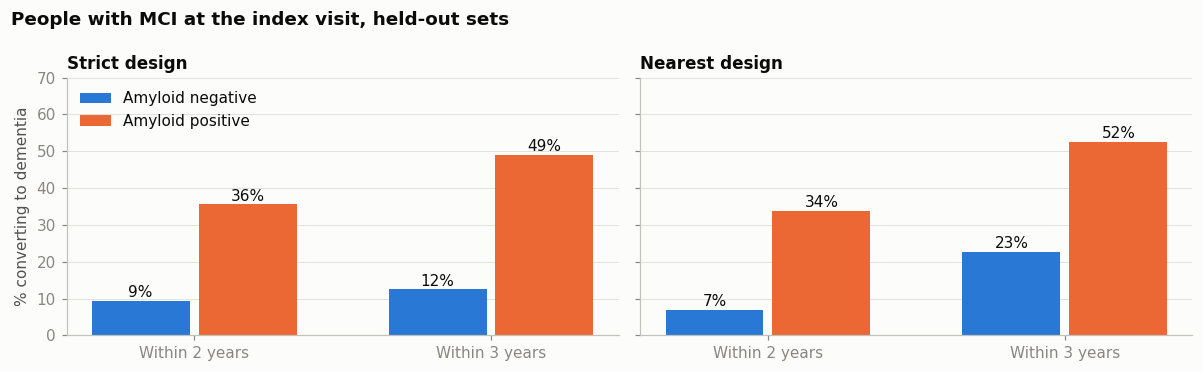

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, design in zip(axes, ["Strict", "Nearest"]):
    sub = rates.xs((design, "MCI at index"), level=(0, 2))
    x = np.arange(2); w = 0.36
    for i, (status, color) in enumerate([("Amyloid negative", nu.BLUE), ("Amyloid positive", nu.ORANGE)]):
        vals = [sub.loc[(h, status), "Rate %"] for h in ["2 years", "3 years"]]
        ax.bar(x + (i - 0.5) * w, vals, width=w - 0.03, color=color, label=status)
        for xi, v in zip(x, vals): ax.text(xi + (i - 0.5) * w, v + 1, f"{v:.0f}%", ha="center")
    ax.set_xticks(x, ["Within 2 years", "Within 3 years"]); ax.grid(axis="x", visible=False); ax.set_ylim(0, 70); ax.set_title(f"{design} design")
axes[0].set_ylabel("% converting to dementia"); axes[0].legend(loc="upper left")
fig.suptitle("People with MCI at the index visit, held-out sets", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "08_conversion_by_amyloid"); plt.show()

Among people with MCI, those who are amyloid positive convert to dementia far more often than those who are amyloid negative: in the held-out sets about 34% against 7% within 2 years in the nearest design, and 36% against 9% in the strict design (which has only 91 such people). Among cognitively normal people almost nobody converts within 2 to 3 years whatever their amyloid status, so there is nothing to predict in that window.

## How can both be true?

Amyloid status is a strong risk marker **when it is the only thing you know**. But the clinical model already knows the person's memory score, CDR-SB and age. In people with MCI, a poor memory score and a higher CDR-SB go together with being amyloid positive, so much of what amyloid would tell the model, it has already inferred from cognition. What PET adds on top is then too small to detect with this many events.

In [7]:
rows = {}
for design in allres:
    for target in allres[design]:
        block = allres[design][target]["has amyloid PET"]["test + external"].get("MCI at index", {})
        for name, m in block.items():
            rows[(design.capitalize(), LABEL[target][-7:], name)] = {"n": m["n"], "Events": m["events"], "AUROC (95% interval)": f"{m['auroc']:.3f} ({m['auroc_ci'][0]:.3f}-{m['auroc_ci'][1]:.3f})",
                                                                      "Gain vs clinical only": "reference" if "delta_auroc" not in m else f"{m['delta_auroc']:+.4f} ({m['delta_auroc_ci'][0]:+.4f} to {m['delta_auroc_ci'][1]:+.4f})"}
print("Within people who had MCI at the index visit (test and external pooled):")
pd.DataFrame(rows).T

Within people who had MCI at the index visit (test and external pooled):


n Events AUROC (95% interval)  \
Strict  2 years Clinical only        94     27  0.824 (0.728-0.914)   
                Clinical + amyloid   94     27  0.834 (0.737-0.923)   
        3 years Clinical only        78     31  0.857 (0.778-0.932)   
                Clinical + amyloid   78     31  0.879 (0.795-0.947)   
Nearest 2 years Clinical only       245     61  0.830 (0.768-0.884)   
                Clinical + amyloid  245     61  0.831 (0.768-0.883)   
        3 years Clinical only       179     80  0.860 (0.805-0.911)   
                Clinical + amyloid  179     80  0.859 (0.800-0.909)   

                                           Gain vs clinical only  
Strict  2 years Clinical only                          reference  
                Clinical + amyloid  +0.0100 (-0.0335 to +0.0715)  
        3 years Clinical only                          reference  
                Clinical + amyloid  +0.0226 (-0.0133 to +0.0714)  
Nearest 2 years Clinical only                          reference  
                Clinical + amyloid  +0.0003 (-0.0075 to +0.0098)  
        3 years Clinical only                          reference  
                Clinical + amyloid  -0.0009 (-0.0153 to +0.0156)

Restricted to people with MCI, where amyloid status separates converters so clearly on its own, the nearest design shows no change at all (within 0.001). The strict design shows +0.01 to +0.02, again with intervals that include zero.

## What can and cannot be claimed

**Can be claimed**

* In this cohort, over 2 to 3 years, adding amyloid and tau PET summary measures to a clinical model that includes cognitive tests and CDR-SB did not produce a demonstrable improvement in discrimination, under either way of matching scans to visits.
* Amyloid positivity on its own is strongly associated with conversion among people with MCI, in line with the literature.

**Cannot be claimed**

* "PET is not useful." In the clean (strict) design there are only about 30 events, and the intervals are wide enough to hide a gain of 0.02 to 0.03 AUROC. The correct wording is "no gain was demonstrated", with the interval.
* Anything about cognitively normal people. PET is expected to matter most there, years before symptoms, but with zero or one conversion in the held-out sets this dataset cannot test it. That needs longer follow-up after the scan than exists yet.
* Anything about longer horizons. Amyloid changes precede dementia by a decade or more; a 2 to 3 year window favours measures of current function.

**Consequence for the system.** PET stays in the design as an **optional** input. The late-fusion structure used here is exactly what the interface needs: a person without PET gets the clinical risk; a person with PET gets the fused estimate. The interface states that the two should be treated as similar on current evidence.